# 01-Container Orchestration Fundamentals (kubectl & Pods)

Across Section 22 we treated relationships as first-class data: modeling entities as nodes and edges, running community detection, and finally shipping enterprise knowledge graphs with governance controls in Neo4j. That section ended by asking a systems question none of those chapters actually answered: once a model, a graph store, or an API server is trained and validated, *where does it physically run, and how does it stay running when a machine dies at 3 a.m.?*

That is the question this entire new section answers. Every artifact you have produced so far — a scikit-learn pickle, a PyTorch checkpoint, a Neo4j container, a FastAPI service — is, from the operating system's point of view, just a process wrapped in a Linux namespace and a cgroup. **Kubernetes** is the distributed control plane that takes thousands of these wrapped processes across a fleet of machines and keeps them in a *declared* state, automatically, forever, without a human re-running a deploy script at 3 a.m.

We start at the bottom of the stack: the **Pod**, Kubernetes' atomic unit of scheduling, and **kubectl**, the imperative command-line client that talks to the cluster's API server. Before we can reason about autoscaling (Lesson 02), rollout strategies (Lesson 03), or distributed GPU training (Lessons 05-10), we need to internalize how the scheduler decides *which physical machine* a workload lands on, and how the cluster continuously reconciles what is *running* against what is *desired*. The tool for this lesson is **kubectl**, backed by the Kubernetes Python client for programmatic access.

## 1. The Scheduling Physics of the Container Orchestrator

### The Pod as Atomic Scheduling Unit

A container is a process isolated by Linux namespaces (PID, NET, MNT, UTS, IPC) and resource-bounded by cgroups. Kubernetes never schedules a bare container — it schedules a **Pod**, defined as an ordered set of co-located containers $\{c_1, c_2, \dots, c_m\}$ that share a network namespace (one IP) and, optionally, storage volumes. Formally, a Pod $p$ carries a resource request vector

$$r_p = \left(r_p^{cpu}, r_p^{mem}\right), \qquad r_p^{cpu} = \sum_{i=1}^m r_{c_i}^{cpu}, \quad r_p^{mem} = \sum_{i=1}^m r_{c_i}^{mem}$$

and this vector, not the container boundary, is the unit the scheduler reasons about. This is why a sidecar container (e.g. a log shipper) is scheduled *atomically* with its main application container — they either land on the same node together or not at all.

### Predicate Filtering and Priority Scoring (Bin Packing)

Placing a Pod onto one of $N$ nodes is a constrained combinatorial optimization problem, solved in two phases by `kube-scheduler`.

**Phase 1 — Predicates (Filtering).** A node $n$ with capacity $C_n = (C_n^{cpu}, C_n^{mem})$ is *feasible* for pod $p$ only if it survives every hard predicate, most importantly the capacity constraint over all pods $q$ already bound to $n$:

$$\text{Feasible}(n, p) \iff \left(\sum_{q \in \text{Pods}(n)} r_q^{cpu}\right) + r_p^{cpu} \le C_n^{cpu} \;\;\land\;\; \left(\sum_{q \in \text{Pods}(n)} r_q^{mem}\right) + r_p^{mem} \le C_n^{mem}$$

along with taints/tolerations, node selectors, and affinity rules (revisited in Lesson 08 for GPU topology). This is a multi-dimensional **bin packing** problem: nodes are bins of capacity $C_n$, Pods are items of size $r_p$, and the scheduler must pack items without exceeding any bin's capacity along *either* dimension simultaneously.

**Phase 2 — Priorities (Scoring).** Among all feasible nodes $\mathcal{F}(p) = \{n : \text{Feasible}(n, p)\}$, each node receives a weighted score from $k$ priority functions $f_i$ (e.g. `LeastRequestedPriority`, `BalancedResourceAllocation`, `InterPodAntiAffinity`):

$$\text{score}(n, p) = \sum_{i=1}^{k} w_i \cdot f_i(n, p), \qquad n^\star = \arg\max_{n \in \mathcal{F}(p)} \text{score}(n, p)$$

The Pod is bound to $n^\star$. A common simplified heuristic we simulate below is **best-fit-decreasing**: sort pods by descending resource request, and for each, choose the feasible node with the *smallest* residual capacity after placement — this minimizes wasted fragmentation versus naive first-fit.

### The Reconciliation Control Loop (Declarative Convergence)

Kubernetes is declarative, not imperative: `kubectl apply -f deployment.yaml` does not "run" anything — it writes a **desired state** $S_{desired}$ into `etcd`. A family of controllers continuously observes the **actual state** $S_{observed}$ and computes a diff:

$$\Delta(S_{desired}, S_{observed}) = S_{desired} \setminus S_{observed}$$

Each control loop iteration applies a corrective action $A$ such that $S_{observed} \leftarrow S_{observed} + A$, repeating until $\Delta = \varnothing$. This is why deleting a Pod from a Deployment does not "delete" the workload — the ReplicaSet controller observes $|\text{Pods}_{observed}| < \text{replicas}_{desired}$ and immediately schedules a replacement. The convergence is asymptotically stable: as long as $A$ is monotonic toward reducing $\Delta$, the system reaches $S_{observed} = S_{desired}$ regardless of the failure that caused the divergence.

## 2. Imperative Execution: Simulating a kubectl-Driven Cluster

We will author real Namespace, Deployment, and Service manifests exactly as `kubectl apply -f` would consume them, then simulate the `kube-scheduler` predicate/priority pipeline in pure Python against a toy 3-node cluster, since no live API server exists in this sandbox.

In [1]:
# Required installations: pip install kubernetes pyyaml

import os
import yaml

print("--- 🚀 Initializing kubectl Cluster Orchestration Sandbox ---")

# 1. Define a toy 3-node cluster with heterogeneous capacity (vCPU cores, GiB memory)
nodes = {
    "node-a": {"cpu": 8, "mem": 32},
    "node-b": {"cpu": 4, "mem": 16},
    "node-c": {"cpu": 16, "mem": 64},
}

# 2. Define a batch of Pods to schedule, each carrying a resource REQUEST (requests drive scheduling, not limits)
pods = [
    {"name": "web-frontend-1", "cpu": 1, "mem": 2},
    {"name": "web-frontend-2", "cpu": 1, "mem": 2},
    {"name": "api-backend-1", "cpu": 2, "mem": 4},
    {"name": "api-backend-2", "cpu": 2, "mem": 4},
    {"name": "redis-cache", "cpu": 1, "mem": 8},
    {"name": "batch-worker-1", "cpu": 4, "mem": 8},
    {"name": "batch-worker-2", "cpu": 4, "mem": 8},
    {"name": "ml-inference", "cpu": 6, "mem": 12},
]

# 3. Author real Namespace + Deployment + Service manifests, exactly what `kubectl apply -f` would ingest
namespace_manifest = {
    "apiVersion": "v1",
    "kind": "Namespace",
    "metadata": {"name": "ml-workloads"},
}

deployment_manifest = {
    "apiVersion": "apps/v1",
    "kind": "Deployment",
    "metadata": {"name": "api-backend", "namespace": "ml-workloads"},
    "spec": {
        "replicas": 2,
        "selector": {"matchLabels": {"app": "api-backend"}},
        "template": {
            "metadata": {"labels": {"app": "api-backend"}},
            "spec": {
                "containers": [{
                    "name": "api-backend",
                    "image": "registry.local/api-backend:1.4.0",
                    "resources": {
                        "requests": {"cpu": "2", "memory": "4Gi"},
                        "limits": {"cpu": "2", "memory": "4Gi"},
                    },
                }]
            },
        },
    },
}

service_manifest = {
    "apiVersion": "v1",
    "kind": "Service",
    "metadata": {"name": "api-backend-svc", "namespace": "ml-workloads"},
    "spec": {
        "selector": {"app": "api-backend"},
        "ports": [{"port": 80, "targetPort": 8080}],
        "type": "ClusterIP",
    },
}

os.makedirs("k8s_manifests", exist_ok=True)
with open("k8s_manifests/namespace.yaml", "w") as f:
    yaml.dump(namespace_manifest, f, sort_keys=False)
with open("k8s_manifests/deployment.yaml", "w") as f:
    yaml.dump(deployment_manifest, f, sort_keys=False)
with open("k8s_manifests/service.yaml", "w") as f:
    yaml.dump(service_manifest, f, sort_keys=False)

print("   ✅ Namespace, Deployment, and Service manifests compiled to k8s_manifests/")

print("\n--- 🧮 Executing kubectl apply Simulation (Predicate + Priority Scheduler) ---")

schedule = {n: [] for n in nodes}
usage = {n: {"cpu": 0, "mem": 0} for n in nodes}

def best_fit_score(node_cap, node_usage, pod):
    # Predicate check + priority score: smaller residual capacity after placement wins (best-fit-decreasing).
    residual_cpu = node_cap["cpu"] - node_usage["cpu"] - pod["cpu"]
    residual_mem = node_cap["mem"] - node_usage["mem"] - pod["mem"]
    if residual_cpu < 0 or residual_mem < 0:
        return None
    return residual_cpu + residual_mem

try:
    from kubernetes import client, config
    config.load_kube_config()
    v1 = client.CoreV1Api()
    node_list = v1.list_node()
    print(f"   Connected to live cluster with {len(node_list.items)} nodes.")
except Exception as e:
    print("   [SYSTEM NOTE]: No live Kubernetes API server reachable in this sandbox -- simulating the")
    print("   kube-scheduler predicate/priority pipeline in pure Python against the toy 3-node cluster.")
    for pod in sorted(pods, key=lambda p: p["cpu"], reverse=True):
        candidates = []
        for n, cap in nodes.items():
            s = best_fit_score(cap, usage[n], pod)
            if s is not None:
                candidates.append((s, n))
        if not candidates:
            print(f"   ⚠️ Pod '{pod['name']}' is UNSCHEDULABLE -- no node satisfies the capacity predicate.")
            continue
        candidates.sort(key=lambda x: x[0])
        chosen_node = candidates[0][1]
        schedule[chosen_node].append(pod["name"])
        usage[chosen_node]["cpu"] += pod["cpu"]
        usage[chosen_node]["mem"] += pod["mem"]
        print(f"   ✅ Pod '{pod['name']:<16}' (cpu={pod['cpu']}, mem={pod['mem']}Gi) -> scheduled on {chosen_node}")


--- 🚀 Initializing kubectl Cluster Orchestration Sandbox ---
   ✅ Namespace, Deployment, and Service manifests compiled to k8s_manifests/

--- 🧮 Executing kubectl apply Simulation (Predicate + Priority Scheduler) ---
   [SYSTEM NOTE]: No live Kubernetes API server reachable in this sandbox -- simulating the
   kube-scheduler predicate/priority pipeline in pure Python against the toy 3-node cluster.
   ✅ Pod 'ml-inference    ' (cpu=6, mem=12Gi) -> scheduled on node-a
   ✅ Pod 'batch-worker-1  ' (cpu=4, mem=8Gi) -> scheduled on node-b
   ✅ Pod 'batch-worker-2  ' (cpu=4, mem=8Gi) -> scheduled on node-c
   ✅ Pod 'api-backend-1   ' (cpu=2, mem=4Gi) -> scheduled on node-a
   ✅ Pod 'api-backend-2   ' (cpu=2, mem=4Gi) -> scheduled on node-c
   ✅ Pod 'web-frontend-1  ' (cpu=1, mem=2Gi) -> scheduled on node-c
   ✅ Pod 'web-frontend-2  ' (cpu=1, mem=2Gi) -> scheduled on node-c
   ✅ Pod 'redis-cache     ' (cpu=1, mem=8Gi) -> scheduled on node-c


## 3. Declarative Telemetry: The Cluster Reconciliation Audit

Once the scheduler has bound every Pod, we audit the resulting cluster state exactly as `kubectl get pods -o wide` and `kubectl top nodes` would report it, cross-referencing allocation against raw node capacity.

In [2]:
print("\n--- 🔍 Auditing the Cluster Reconciliation State ---")

print(f"{'Node':<10} | {'Pods Scheduled':<48} | {'CPU Util':<10} | {'Mem Util'}")
print("-" * 95)
for n, cap in nodes.items():
    pod_names = ", ".join(schedule[n]) if schedule[n] else "(idle)"
    cpu_pct = usage[n]["cpu"] / cap["cpu"] * 100
    mem_pct = usage[n]["mem"] / cap["mem"] * 100
    print(f"{n:<10} | {pod_names:<48} | {cpu_pct:>7.1f}% | {mem_pct:>7.1f}%")

print("\n[OPERATIONAL INSIGHT]")
print("-> A Pod is only feasible when BOTH residual_cpu >= 0 AND residual_mem >= 0 hold simultaneously --")
print("   the scheduler never optimizes a single resource dimension in isolation.")
print("-> Best-fit-decreasing ordering (largest CPU request placed first) reduces fragmentation versus")
print("   naive first-fit: 'ml-inference' (cpu=6) claims its slot before smaller pods compete for it.")
print("-> node-b (4 vCPU / 16Gi) is the tightest-fit node in the cluster and saturates first -- this is")
print("   exactly the pressure signal an HPA/VPA controller (Lesson 02) reacts to.")
print("-> The manifests on disk are idempotent: re-running `kubectl apply -f k8s_manifests/` against a")
print("   live API server converges to the identical desired state with zero side effects.")



--- 🔍 Auditing the Cluster Reconciliation State ---
Node       | Pods Scheduled                                   | CPU Util   | Mem Util
-----------------------------------------------------------------------------------------------
node-a     | ml-inference, api-backend-1                      |   100.0% |    50.0%
node-b     | batch-worker-1                                   |   100.0% |    50.0%
node-c     | batch-worker-2, api-backend-2, web-frontend-1, web-frontend-2, redis-cache |    56.2% |    37.5%

[OPERATIONAL INSIGHT]
-> A Pod is only feasible when BOTH residual_cpu >= 0 AND residual_mem >= 0 hold simultaneously --
   the scheduler never optimizes a single resource dimension in isolation.
-> Best-fit-decreasing ordering (largest CPU request placed first) reduces fragmentation versus
   naive first-fit: 'ml-inference' (cpu=6) claims its slot before smaller pods compete for it.
-> node-b (4 vCPU / 16Gi) is the tightest-fit node in the cluster and saturates first -- this is
  

## 4. Visualizing Cluster Topology (Node & Pod Bin-Packing Diagram)

We render each node as a vertical bin whose height is its CPU capacity, stacking each scheduled Pod as a block sized by its CPU request -- a direct visualization of the bin-packing solution the scheduler computed above.

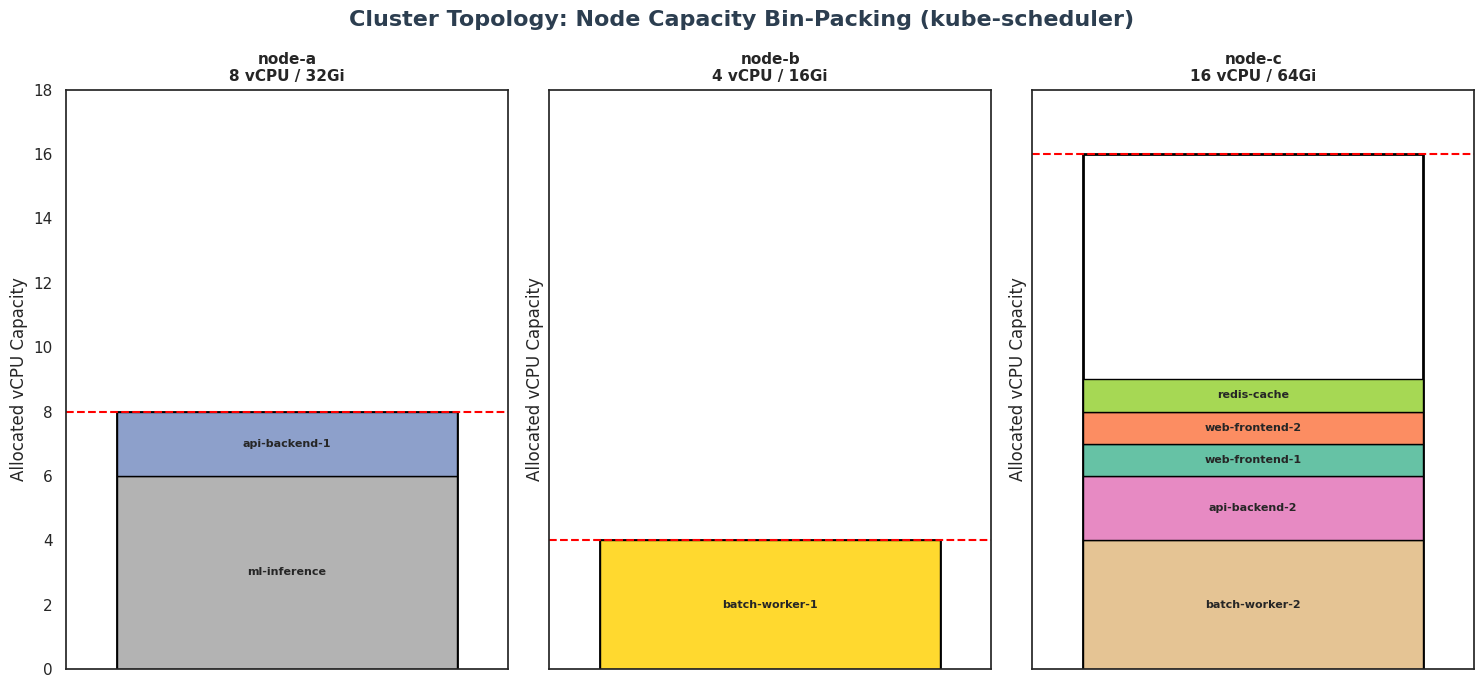

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="white")

fig, axes = plt.subplots(1, len(nodes), figsize=(15, 7), sharey=True)
fig.suptitle("Cluster Topology: Node Capacity Bin-Packing (kube-scheduler)", fontsize=16, fontweight='bold', color="#2c3e50")

palette = sns.color_palette("Set2", n_colors=len(pods))
pod_colors = {p["name"]: palette[i] for i, p in enumerate(pods)}
max_cap = max(cap["cpu"] for cap in nodes.values())

for ax, (n, cap) in zip(axes, nodes.items()):
    ax.set_title(f"{n}\n{cap['cpu']} vCPU / {cap['mem']}Gi", fontsize=11, fontweight='bold')
    ax.add_patch(patches.Rectangle((0, 0), 1, cap["cpu"], fill=False, edgecolor="black", lw=2))
    y = 0
    for pod_name in schedule[n]:
        pod = next(p for p in pods if p["name"] == pod_name)
        ax.add_patch(patches.Rectangle((0, y), 1, pod["cpu"], fill=True, facecolor=pod_colors[pod_name], edgecolor="black", lw=1))
        ax.text(0.5, y + pod["cpu"] / 2, pod_name, ha='center', va='center', fontsize=8, fontweight='bold')
        y += pod["cpu"]
    ax.axhline(cap["cpu"], color="red", ls="--", lw=1.5)
    ax.set_xlim(-0.15, 1.15)
    ax.set_ylim(0, max_cap + 2)
    ax.set_xticks([])
    ax.set_ylabel("Allocated vCPU Capacity")

plt.tight_layout()
plt.show()


*(Insight: Each colored block is one Pod's CPU footprint stacked bottom-up inside its host node's capacity envelope, with the red dashed line marking the hard ceiling `kube-scheduler` will never cross. `node-c`, the largest bin, absorbs the heaviest pods (`ml-inference`, the batch workers) while still leaving headroom -- exactly what a balanced-resource priority function rewards. `node-b`'s stack visibly approaches its red line, making the coming autoscaling pressure in Lesson 02 visually obvious before a single metric is even collected.)*

## Real-World Use Case or Analogy

Think of a Kubernetes cluster as **The Container Shipping Port**:

* **The Pod (The Shipping Container):** A standardized steel box. The port doesn't care what's packed inside (your app + its sidecar log shipper) -- it only cares about the box's declared weight and dimensions (CPU/memory requests).
* **The Node (The Cargo Ship):** Each ship has a hard, physical weight limit. Overload it and it capsizes -- exactly like exceeding a node's `C_n^{cpu}` capacity crashes the kubelet's admission control.
* **kube-scheduler (The Harbor Master):** Before any container is craned aboard, the harbor master checks every ship's manifest (predicate filtering) and picks the ship that balances the load best (priority scoring) -- never eyeballing it, always running the numbers.
* **kubectl apply (The Shipping Order):** You don't personally load containers. You submit a shipping order describing what should be on which route (`desired state`), and the port's own machinery executes and re-executes it until reality matches the order.
* **The Reconciliation Loop (The Night Watch):** If a container falls overboard in a storm (a Pod crashes), the night watch doesn't wait for a human to notice -- it immediately cranes a replacement container aboard from the depot, restoring the manifest count without anyone being paged.
* **The Namespace (The Terminal Zone):** Large ports partition into Terminal A, Terminal B, etc., so that "ml-workloads" cargo never gets mixed up with "finance-reporting" cargo, even though they share the same physical harbor.

Once you see Pods as containers, nodes as ships, and the scheduler as a tireless, math-driven harbor master, every subsequent Kubernetes concept -- autoscaling, rollouts, GPU topology -- is just a refinement of this same loading-and-reconciliation physics.